## Installations and Imports

In [1]:
# In case you don't have qiskit, install it now
%pip install qiskit --quiet
%pip install qiskit-aer --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Installing/upgrading pylatexenc seems to have fixed my mpl issue
# If you try this and it doesn't work, try also restarting the runtime/kernel
%pip install pylatexenc --quiet
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Let's go ahead and import all this stuff too
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import numpy as np
from qiskit.visualization import plot_histogram, plot_state_qsphere, plot_bloch_multivector, plot_bloch_vector
import getpass
import random
import os
from IPython.display import clear_output
import time

# Card definition

In [4]:
'''
Stores the values of each individual card
Gate cards store a quantum circuit with their respective gate
Action and other special cards will just stored id information, to be interpreted
and handled by the game class
'''
class Card:
    def __init__(self, type, values = []):
        self.qc = QuantumCircuit(1)
        self.measure = False
        self.gate = False
        self.qi = False
        self.playable = True

        #with a single-computer system, nopes are hard to implement; may ignore for scope
        self.nope = False

        self.type = type
        match self.type:
            case "H":
                self.gate = True
                self.qc.h(0)
            case "X":
                self.gate = True
                self.qc.x(0)
            case "I":
                self.gate = True
                self.qc.id(0)
            case "Y":
                self.gate = True
                self.qc.y(0)
            case "Z":
                self.gate = True
                self.qc.z(0)
            case "S":
                self.gate = True
                self.qc.s(0)
            case "T":
                self.gate = True
                self.qc.t(0)
            case "Measure":
                self.gate = False
                self.measure = True
            case "Quantum Immortality":
                self.qi = True
                self.playable = False
            case "Nope":
                self.nope = True
        # otherwise is an action card
        #"None", "Dead", or "Alive"; if "Dead", out for the rest of the game
        self.measure_result = "None"

    #Accessor Methods
    def __str__(self):
        return f"type"

    def isGate(self):
        return self.gate

    def isMeasure(self):
        return self.measure

    def isQuantumImmortality(self):
        return self.qi

    def isAction(self):
        return not self.isGate() and not self.isMeasure() and not self.isQuantumImmortality() and not self.isNope()

    def isNope(self):
        return self.nope


    '''
    qc - the quantum register of the game state
    indices - list of which players / qubit(s) to apply gate to
    '''

    def apply_card(self, qc, indices):
        if self.gate:
            qc.compose(self.qc, indices, inplace=True)
    
    def get_label(self):
        return self.type


# Player Class Definition

In [5]:
'''
Stores the state of each player, storing their hand (cards), id # (both global 
and within the current quantum circuit), a reference to the global circuit, 
and their alive/dead state
'''
class Player:
    def __init__(self, player_id, qc):
        self.hand = []
        self.hand.append(Card("Quantum Immortality")) #Every player starts with QI card
        self.alive = True
        self.player_id = player_id
        self.qubit_id = player_id #for now, will need to change when players get elimnated
        self.qc = qc #global qc of this game state
    
    #Accessor Methods
    def get_card_count(self):
        return len(self.hand)
    
    def get_card(self, i):
        return self.hand[i]
    
    def is_alive(self):
        return self.alive

    def get_player_id(self):
        return self.player_id
    
    def get_qubit_id(self):
        return self.qubit_id
    
    #Modifier Methods
    def remove_card(self, i):
        self.hand.pop(i)
        
    def add_card(self, card):
        self.hand.append(card)

    def remove_QI(self):
        for i in self.get_card_count():
            if self.hand[i].type == "Quantum Immortality":
                self.remove_card(i)
                return True
        return False
    
    #Yeesh
    def kill(self):
        self.alive = False
        self.qubit_id = -1

    def put_qc(self, qc):
        self.qc = qc

    def put_qubit_id(self, id):
        self.qubit_id = id

    #Draws the player's qubit
    def draw(self):
        state = Statevector.from_instruction(self.qc)
        dm = DensityMatrix(state)
        keep_dm = partial_trace(dm, [i for i in range(self.qc.num_qubits) if i != self.player_id])
        fig = plot_bloch_multivector(keep_dm)

        # img_path = "assets/bloch.png"
        # fig.savefig(img_path)
        # plt.close(fig)
        display(fig)

# GameState class definition

In [6]:
'''
Types of cards:

Single Gate cards => applies a gate to a player of your choosing, including yourself
H
X
I
Y
Z
S
T
U (TODO)

Double Gate card => apply a gate to two player's cards (TODO)
CNOT
SWAP

Measure cards => the "exploding kitten"; will measure the gate and determine results

Quantum Immortality cards => unplayable; will save one from a badly measured fate

Nope cards => special card that cancels a move, can be played anytime ()

Action cards => game actions one can take
Attack - force a player to take a turn 4
See the future - see the next three cards in the deck 5
Shuffle - shuffles the deck 4
Favor - steal a player's card of that player's choosing 4
Skip - end your turn without drawing 4

See another - see another person's qubit
Publish Paper - make one qubit public for that moment
'''

class GameState:
    card_labels = [
        "H",
        "X",
        "I",
        "Y",
        "Z",
        "S",
        "T",
        #"CNOT",
        "SWAP",
        "Measure",
        "Quantum Immortality",
        "Nope",
        "Attack",
        "See the future",
        "Shuffle",
        "Favor",
        "Skip",
        "See Another",
        "Publish Paper"

    ]

    
    '''
    Defines the game instance. The user interface should be able
    to query this function for all needs. Takes qc in and does
    game relevant manipulation.
    '''
    def __init__(self, num_players):
        #Init players
        self.players = []
        self.current_player = 0
        self.players_alive = num_players
        self.players_total = num_players
        self.master_qc = QuantumCircuit(self.players_alive, self.players_alive)
        for i in range(self.players_alive):
            self.master_qc.h(i)
        for i in range(self.players_alive):
            self.players.append(Player(i, self.master_qc))
        

        #Init deck w/out measures or quantum immortalities
        self.deck = []
        for i in range(self.players_alive):
            for label in GameState.card_labels:
                if label != "Measure" and label != "Quantum Immortality":
                    self.deck.append(Card(label))
        random.shuffle(self.deck)

        #Init player hands
        rng = np.random.default_rng()
        for i in range(self.players_alive):
            for j in range(6):
                r = rng.integers(0, len(self.deck))
                self.players[i].hand.append(self.deck.pop(i))
        random.shuffle(self.deck)
        
        #Add quantum immortalities and measures to deck
        for i in range(self.players_alive):
            for label in GameState.card_labels:
                self.deck.append(Card(label))
        random.shuffle(self.deck)
        
        
    def setup_qc(self):
        """
        Sets up a new instance after measurement based on living players
        Sets the players' new qubit_ids
        """
        self.master_qc = QuantumCircuit(self.players_alive, self.players_alive)
        for i in range(self.players_alive):
            self.master_qc.h(i)
        qubit_id = 0
        for i in range(self.players_total):
            current_player = self.get_player(i)
            if current_player.is_alive():
                current_player.put_qc(self.master_qc)
                current_player.put_qubit_id(qubit_id)
                qubit_id = qubit_id + 1
    
    #Accessor Methods
    def get_current_player(self):
        return self.players[self.current_player]
    
    def get_player(self, i):
        return self.players[i]
    
    def player_is_alive(self, i):
        return self.players[i].is_alive()
    
    def get_deck(self):
        return self.deck

    def player_count(self):
        return self.players_total
    
    def get_qc(self):
        return self.master_qc
    
    def get_alive_count(self):
        return self.players_alive

    
    #Kills the i'th player
    def kill_player(self, i):
        self.kill(self.get_player(i))
        self.players_alive = self.players_alive - 1
        
    #Increases player index, looping when necessary
    def set_next_player(self):
        self.current_player = (self.current_player + 1) % self.players_total
        while (not self.player_is_alive(self.current_player)):
            self.current_player = (self.current_player + 1) % self.players_total
            
    #Shuffles the card deck
    def shuffle_deck(self):
        random.shuffle(self.deck)


# Gameplay loop

In [ ]:
class Game:
    def __init__(self, num_players):
        self.state = GameState(num_players)
    
    def measure(self):
        """
        What needs to happen in this method:
        - One shot the circuit
        - for every 1 found:
            - QI => remove QI
                - if no player dies, must reinsert
            - no QI => eliminated
        - construct new quantum circuit minus eliminated players in game state
        - initialize THOSE proper states
        - save this qc in game state AND every living player
        returns number of a WINNER if there is a winner, -1 if game continues, -2 if everyone lost
        """ 
        self.clear_terminal()
        print("A measurement was drawn!")
        print("Everyone's states:")
        
        state = Statevector.from_instruction(self.state.master_qc)
        dm = DensityMatrix(state)
        fig = plot_bloch_multivector(dm)
        # img_path = "assets/bloch.png"
        # fig.savefig(img_path)
        # plt.close(fig)
        display(fig)

        self.state.master_qc.measure_all()
        #run the counts
        backend = Aer.get_backend('qasm_simulator')
        #hashmap of values
        counts= backend.run(self.state.get_qc(), shots=1).result().get_counts(self.state.get_qc())
        bit_string = counts.keys()[0]

        
        player_i = 0
        replace_measurement_card = True
        winner_player_id = -1
        for qubit_i in len(bit_string):
            while not self.state.get_player(player_i).is_alive():
                player_i = player_i + 1
            player = self.state.get_player(player_i)
            #qubit_i should now correlate to the correct player
            if bit_string[qubit_i] == "0":
                print(f"Player {player_i} status: 0, ALIVE")
                winner_player_id = player_i
            else:
                if player.remove_QI():
                    print(f"Player {player_i} status: 1, DEAD, SAVED BY QUANTUM IMMORTALITY CARD")
                else:
                    print(f"Player {player_i} status: 1, DEAD, ELIMINATED")
                    replace_measurement_card = False
                    self.state.kill_player(player_i)
        if replace_measurement_card:
            # TODO; replace measurement card in a random place in the deck
            "TODO"
        match self.state.get_alive_count():
            case 1:
                return winner_player_id
            case 0:
                return -2
            
        # default case; setup continuing the game
        self.state.setup_qc()
        return -1




    def clear_terminal(self):
        """Clears the terminal screen."""
        os.system('clear')
        clear_output()
    
    """Selects a player for some action"""
    def select_target_player_screen(self):
        chosen_target = -1
        while (chosen_target==-1):
            try:
                move = int(input("Choose a target player: "))
                if (move < 0 or move >= self.state.player_count()):
                    print("Invalid input. Please enter a valid integer.")
                    continue
                elif not self.state.player_is_alive(move):
                    print("That player is already dead! Choose another")
                    continue
                chosen_target = move
            except ValueError:
                print("Invalid input. Please enter a valid integer.")
        return chosen_target
    
    """Selects a card for some action"""
    def select_card_screen(self, current_player):
        print("Your moves:")
        for i in range(current_player.get_card_count()):
            print(f"{i}. {current_player.get_card(i).get_label()}")
        print(f"{current_player.get_card_count()}. Draw a card and end your turn")
        chosen_index = -1
        while (chosen_index==-1):
            try:
                move = int(input("Choose a card: "))
                if (move < 0 or move > current_player.get_card_count()):
                    print("Invalid input. Please enter a valid integer.")
                    continue
                elif (move !=  current_player.get_card_count() and (current_player.get_card(move).get_label() == "Nope"
                    or current_player.get_card(move).get_label() == "Quantum Immortality")):
                    print("You can't play that card!")
                    continue
                chosen_index = move
            except ValueError:
                print("Invalid input. Please enter a valid integer.")
        return chosen_index

    """
    Takes one turn for one player.
    Returns a winner integer if this turn ends with a winner
    Returns -2 if this turn ends in total death
    Returns -1 otherwise
    """
    def take_turn(self):
        self.clear_terminal()
        current_player_val = self.state.current_player
        print(f"Player {current_player_val}'s turn.")
        current_player = self.state.get_current_player()
        
        skip = False
        while not skip:
            print("Your state:")
            current_player.draw()
            
            chosen_index = self.select_card_screen(current_player)

            if chosen_index == current_player.get_card_count():
                #The player has chosen to end their turn
                #MOST cases will end like this
                break
            
            self.clear_terminal()
            print(f"Player {current_player_val}'s turn.")
            chosen_card = current_player.get_card(chosen_index)
            
            #Perform your move
            if chosen_card.isGate():
                #case; need to query who is getting this gate
                chosen_target = self.select_target_player_screen()
                #translate player_id to qubit_id
                chosen_card.apply_card(self.state.get_qc(), [self.state.get_player(chosen_target).get_qubit_id()])
                

            elif chosen_card.isAction():
                #should happen if not isGate():
                match chosen_card.get_label():
                    # Attack - force a player to take a turn 4
                    # See the future - see the next three cards in the deck 5
                    # Shuffle - shuffles the deck 4
                    # Favor - steal a player's card of that player's choosing 4
                    # Skip - end your turn without drawing 4

                    # See another - see another person's qubit
                    # Publish Paper - make one qubit public for that moment
                    case "Attack":
                        #TODO decide what attack to do
                        "TODO"
                    case "See the future":
                        print("The top three cards are:")
                        deck = self.state.get_deck()
                        if (len(deck) > 0):
                            print(f"0. {deck[0].get_label()}")
                        if (len(deck) > 1):
                            print(f"1. {deck[1].get_label()}")
                        if (len(deck) > 2):
                            print(f"2. {deck[2].get_label()}")
                    case "Shuffle":
                        self.state.shuffle_deck()
                        print("The deck has been shuffled!")
                    case "Favor":
                        print("You get to steal a card from another player!")
                        chosen_target = self.select_target_player_screen()
                        hand = self.state.get_player(chosen_target).get_deck()
                        if hand:  # Ensure the list is not empty
                            random_element = random.choice(hand)
                            hand.remove(random_element)
                            print(f"Player {chosen_target} has given you: {random_element.get_label()}")
                        else:
                            print("They don't have any cards. womp womp.")

                    case "Skip":
                        print("You're skipping your turn!")
                        time.sleep(2)
                        skip = True
                    case "See Another":
                        print("You get to see another player's qubit!")
                        chosen_target = self.select_target_player_screen()
                        print(f"Player {chosen_target}'s qubit:")
                        chosen_player = self.state.get_player(chosen_target)
                        chosen_player.draw()
                    case "Publish Paper":
                        print("EVERYONE gets to see a player's qubit!")
                        chosen_target = self.select_target_player_screen()
                        print(f"Player {chosen_target}'s qubit:")
                        chosen_player = self.state.get_player(chosen_target)
                        chosen_player.draw()
                        input(f"Once everyone has seen the qubit, return the device to Player {current_player_val}.")
                    

            #remove the card for this player
            current_player.remove_card(chosen_index)

        if not skip:
            #Draw a card into the hand
            new_card = self.state.get_deck().pop(0)
            if new_card.get_label() == "Measure":
                result = self.measure()
                match result:
                    case -1:
                        """Do nothing"""
                    case _:
                        #return expected result
                        return result
            else:
                current_player.add_card(new_card)
                print(f"Your new card is: {new_card.get_label()}")
                time.sleep(2)

        #set the next player to do a thing
        self.state.set_next_player()
        return -1
                    

        
        

    '''
    Does the bruntwork of managing the gameplay loop:
    '''
    def gameplay_loop(self):
        # get the setup data
        while self.state.players_alive > 1:
            result = self.take_turn()
            if result != -1:
                if result > -1:
                    print(f"Player {result} wins!")
                else:
                    print("No one won...")
            self.clear_terminal()
            input(f"Player {self.state.get_current_player().get_player_id()}'s turn. Pass laptop and enter to confirm.")



A measurement was drawn!
Everyone's states:


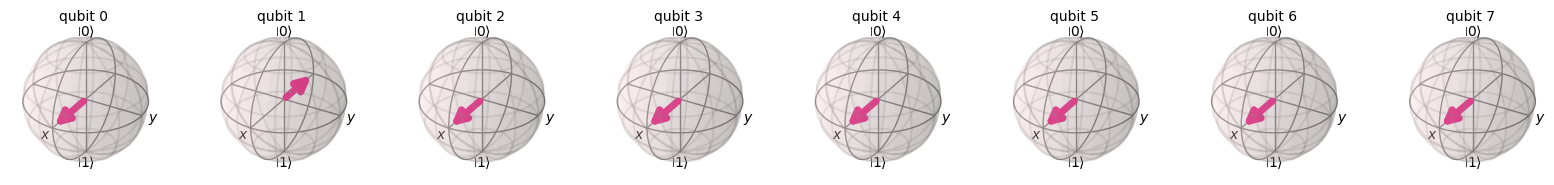

TypeError: 'dict_keys' object is not subscriptable

In [8]:
game = Game(8)
game.gameplay_loop()